In [21]:
import pandas as pd
import requests
from typing import Optional

records = []
# creating room = a list containing 3 lists (1 for each room) with items 1. room name, 2. temperature URL, 3. noise URL
rooms = [
        ("BG.West.010", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(1)/Observations?$orderby=phenomenonTime desc", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(6)/Observations?$orderby=phenomenonTime desc"),
        ("BG.West.270", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(7)/Observations?$orderby=phenomenonTime desc", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(12)/Observations?$orderby=phenomenonTime desc"),
        ("01.West.120", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(13)/Observations?$orderby=phenomenonTime desc", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(18)/Observations?$orderby=phenomenonTime desc"),
    ]
temp_records = []
noise_records = []
# fetch ALL paginated observations from server
def fetch_all_observations(url):
    observations = []
    while url:
        try:
            response = requests.get(url)
            response.raise_for_status()
            data = response.json()
            observations.extend(data.get("value", []))
            url = data.get("@iot.nextLink")  # move to next page if available
        except Exception as e:
            print(f"Error fetching from {url}:\n{e}")
            break
    return observations
for room_name, temp_url, noise_url in rooms:
    temp_obs = fetch_all_observations(temp_url)
    noise_obs = fetch_all_observations(noise_url)

    for obs in temp_obs:
        temp_records.append({
            "room_name": room_name,
            "internal_temp": obs.get("result"),
            "temp_unit": "°C",
            "phenomenon_time": obs.get("phenomenonTime")
        })

    for obs in noise_obs:
        noise_records.append({
            "room_name": room_name,
            "noise": obs.get("result"),
            "noise_unit": "db",
            "phenomenon_time": obs.get("phenomenonTime")
        })

# Creating DataFrames
df_temp = pd.DataFrame(temp_records)
df_noise = pd.DataFrame(noise_records)

# cleaning up the DataFrames
df_temp_cleaned = df_temp.drop_duplicates(subset=["room_name", "phenomenon_time"])
df_noise_cleaned = df_noise.drop_duplicates(subset=["room_name", "phenomenon_time"])
# Preview the result
print("Temperature DataFrame (head):")
print(df_temp_cleaned.head())

print("\nNoise DataFrame (head):")
print(df_noise_cleaned.head())
df_temp_cleaned.shape[0], df_noise_cleaned.shape[0]

Temperature DataFrame (head):
     room_name  internal_temp temp_unit       phenomenon_time
0  BG.West.010           24.7        °C  2025-06-26T04:20:58Z
2  BG.West.010           24.7        °C  2025-06-26T04:10:52Z
4  BG.West.010           24.7        °C  2025-06-26T04:00:47Z
7  BG.West.010           24.6        °C  2025-06-26T03:50:43Z
9  BG.West.010           24.7        °C  2025-06-26T03:40:41Z

Noise DataFrame (head):
     room_name  noise noise_unit       phenomenon_time
0  BG.West.010     36         db  2025-06-26T04:20:58Z
2  BG.West.010     36         db  2025-06-26T04:10:52Z
4  BG.West.010     36         db  2025-06-26T04:00:47Z
7  BG.West.010     36         db  2025-06-26T03:50:43Z
9  BG.West.010     36         db  2025-06-26T03:40:41Z


(34838, 34838)

Temperature Statistics:
               count       mean       std   min   25%   50%   75%   max
room_name                                                              
01.West.120  11333.0  23.488829  1.525794  20.7  22.3  23.0  24.7  27.6
BG.West.010  11959.0  22.400167  1.835280  17.1  21.1  22.0  23.4  28.6
BG.West.270  11546.0  23.534072  1.997980  18.5  21.9  23.5  24.7  29.2
Noise Statistics:
               count       mean       std   min   25%   50%   75%   max
room_name                                                              
01.West.120  11333.0  33.311568  3.712902  32.0  32.0  32.0  33.0  65.0
BG.West.010  11959.0  40.916465  4.243740  34.0  37.0  42.0  43.0  67.0
BG.West.270  11546.0  38.125671  5.945302  31.0  32.0  39.0  41.0  61.0


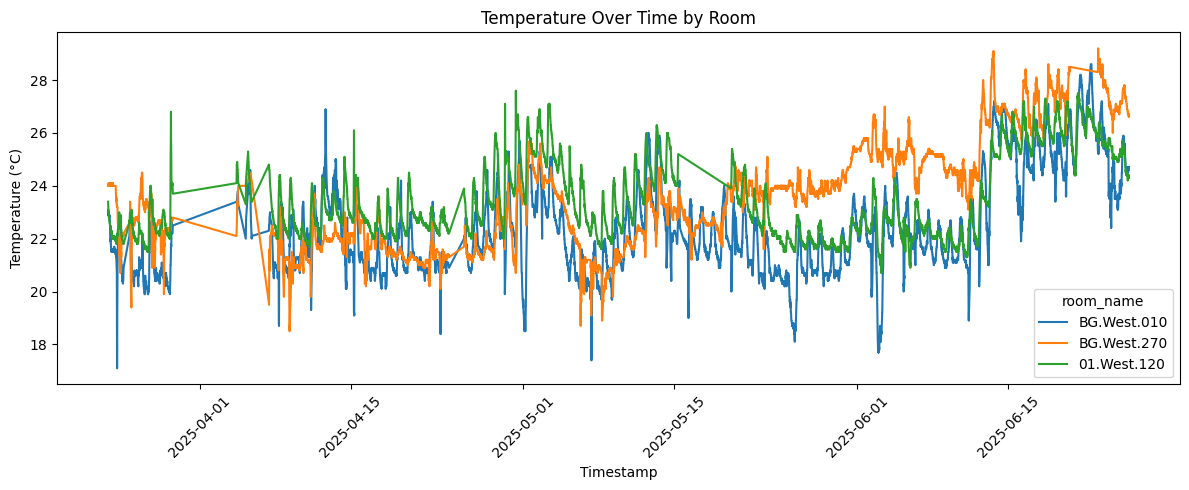

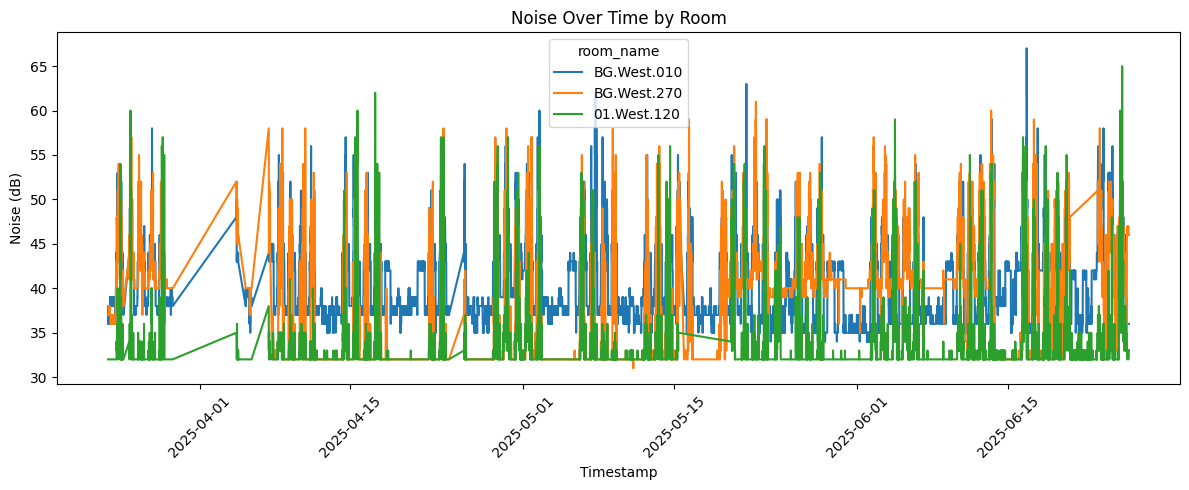

In [22]:
# BASIC DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure datetime format
df_temp_cleaned.loc[:, "phenomenon_time"] = pd.to_datetime(df_temp_cleaned["phenomenon_time"])
df_noise_cleaned.loc[:, "phenomenon_time"] = pd.to_datetime(df_noise_cleaned["phenomenon_time"])

# --------- Statistical Summary ---------
print("Temperature Statistics:")
print(df_temp_cleaned.groupby("room_name")["internal_temp"].describe())

print("Noise Statistics:")
print(df_noise_cleaned.groupby("room_name")["noise"].describe())

# --------- Line Plot: Temperature Over Time ---------
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_temp_cleaned, x="phenomenon_time", y="internal_temp", hue="room_name")
plt.title("Temperature Over Time by Room")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------- Line Plot: Noise Over Time ---------
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_noise_cleaned, x="phenomenon_time", y="noise", hue="room_name")
plt.title("Noise Over Time by Room")
plt.xlabel("Timestamp")
plt.ylabel("Noise (dB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Issues revealed by first glance of data
The chart shows temperature over time for each room. As evident there is a lot of noise in the data and the size is too large to analyse (around 30000 temperature values)
This basic visualisation reveals two issues that need to be tacked - 
1. The time resolution (highest data resolution in terms of time is 10 minutes - based on sensor) needs to be reduced to 30 min, 45 min or 1 hr - selection of this resolution is to be based on the fact that temperature change should be somewhat significant in between two data entries - something like x times the standard deviation (where x<1)
2. Visualisation (chart) will give more insight if it shows a smaller date range (e.g. over a day or a week) instead of the entire 3 months of data being shown at once

#### Underneath codeblocks (two) attempt to tackle these issues by 
### 1. lowering time resolution of data 
and 2. visualising a smaller date range in a chart (dataframe would still have entire data for further analysis and processing)

In [23]:
# Selecting time resolution of data by - Calculating Mean Absolute Change for Different Time Intervals

# defining resampling intervals
intervals = ["10min", "30min", "45min", "1h"]
rooms = df_temp_cleaned["room_name"].unique()
# initialising result table
temp_summary = []
noise_summary = []
for interval in intervals:
    for room in rooms:
        # --- Temperature ---
        temp_room = df_temp_cleaned[df_temp_cleaned["room_name"] == room].copy() # Filter data for the specific room 
        temp_room = temp_room[["phenomenon_time", "internal_temp"]]  # keep only numeric column
        temp_room = temp_room.set_index("phenomenon_time").resample(interval).mean().dropna() # Sets timestamp as index so time-based operations can be performed. Then resamples the data to the specified interval and calculates the mean while ignoring bins with no data
        temp_room["diff"] = temp_room["internal_temp"].diff().abs() # Computes the absolute difference in temperature between consecutive time intervals
        mean_temp_change = temp_room["diff"].mean()
        temp_summary.append({ # Stores the mean change value, linked to its room and interval, in a summary table
            "room": room,
            "interval": interval,
            "mean_temp_change": round(mean_temp_change, 3)
        })

        # --- Noise ---
        noise_room = df_noise_cleaned[df_noise_cleaned["room_name"] == room].copy()
        noise_room = noise_room[["phenomenon_time", "noise"]]  # keep only numeric column
        noise_room = noise_room.set_index("phenomenon_time").resample(interval).mean().dropna()
        noise_room["diff"] = noise_room["noise"].diff().abs()
        mean_noise_change = noise_room["diff"].mean()
        noise_summary.append({
            "room": room,
            "interval": interval,
            "mean_noise_change": round(mean_noise_change, 3)
        })

# Convert to DataFrames for display
df_temp_change = pd.DataFrame(temp_summary)
df_noise_change = pd.DataFrame(noise_summary)

print("\nMean Temperature Change by Interval:")
print(df_temp_change.pivot(index="interval", columns="room", values="mean_temp_change"))

print("\nMean Noise Change by Interval:")
print(df_noise_change.pivot(index="interval", columns="room", values="mean_noise_change"))


Mean Temperature Change by Interval:
room      01.West.120  BG.West.010  BG.West.270
interval                                       
10min           0.042        0.064        0.053
1h              0.149        0.248        0.153
30min           0.085        0.143        0.098
45min           0.117        0.198        0.125

Mean Noise Change by Interval:
room      01.West.120  BG.West.010  BG.West.270
interval                                       
10min           0.684        0.697        0.907
1h              1.052        1.052        1.213
30min           0.863        0.824        0.979
45min           0.950        0.928        1.086


/Users/vb/Desktop/VBThesisCode2_FastAPI/.venv/lib/python3.11/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
/Users/vb/Desktop/VBThesisCode2_FastAPI/.venv/lib/python3.11/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
/Users/vb/Desktop/VBThesisCode2_FastAPI/.venv/lib/python3.11/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dty

Based on these tables, avg temp change per hour (0.15-0.20 Celcius) is a decent granularity for now.

In [24]:
# ─── Create hourly-resampled dataframes ───
hourly_temp_frames = []
hourly_noise_frames = []
for room in rooms:
    # Temperature
    temp_room = df_temp_cleaned[df_temp_cleaned["room_name"] == room].copy()
    temp_room = temp_room[["phenomenon_time", "internal_temp"]]  # keep only numeric column
    temp_room = temp_room.set_index("phenomenon_time").resample("1h").mean().dropna().reset_index() # Sets "phenomenon_time" column as the index of the DataFrame - this is required before I can resample based on time. 
    # resample("1h") groups the data into 1-hour bins (i.e. creates a time-based “groupby”) before averaging each bin for each hour
    # reset_index() converts the datetime index back into a regular column so that phenomenon_time becomes a column again instead of the DataFrame index
    temp_room["room_name"] = room  # add back room info
    hourly_temp_frames.append(temp_room)

    # Noise
    noise_room = df_noise_cleaned[df_noise_cleaned["room_name"] == room].copy()
    noise_room = noise_room[["phenomenon_time", "noise"]]
    noise_room = noise_room.set_index("phenomenon_time").resample("1h").mean().dropna().reset_index()
    noise_room["room_name"] = room
    hourly_noise_frames.append(noise_room)

# Concatenate into new DataFrames
df_temp_hourly = pd.concat(hourly_temp_frames, ignore_index=True)
df_noise_hourly = pd.concat(hourly_noise_frames, ignore_index=True)

# Preview
print("\n✅ Hourly Temperature DataFrame:")
print(df_temp_hourly.head())

print("\n✅ Hourly Noise DataFrame:")
print(df_noise_hourly.head())



✅ Hourly Temperature DataFrame:
            phenomenon_time  internal_temp    room_name
0 2025-03-23 12:00:00+00:00      23.000000  BG.West.010
1 2025-03-23 13:00:00+00:00      22.966667  BG.West.010
2 2025-03-23 14:00:00+00:00      22.816667  BG.West.010
3 2025-03-23 15:00:00+00:00      22.766667  BG.West.010
4 2025-03-23 16:00:00+00:00      22.416667  BG.West.010

✅ Hourly Noise DataFrame:
            phenomenon_time      noise    room_name
0 2025-03-23 12:00:00+00:00  36.600000  BG.West.010
1 2025-03-23 13:00:00+00:00  36.666667  BG.West.010
2 2025-03-23 14:00:00+00:00  36.333333  BG.West.010
3 2025-03-23 15:00:00+00:00  36.500000  BG.West.010
4 2025-03-23 16:00:00+00:00  37.500000  BG.West.010


/Users/vb/Desktop/VBThesisCode2_FastAPI/.venv/lib/python3.11/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
/Users/vb/Desktop/VBThesisCode2_FastAPI/.venv/lib/python3.11/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
/Users/vb/Desktop/VBThesisCode2_FastAPI/.venv/lib/python3.11/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dty

### 2. visualising a smaller date range in a chart 
(dataframe would still have entire data for further analysis and processing)

In [25]:
print(df_temp_hourly["phenomenon_time"].min())
print(df_temp_hourly["phenomenon_time"].max())

2025-03-23 12:00:00+00:00
2025-06-26 04:00:00+00:00


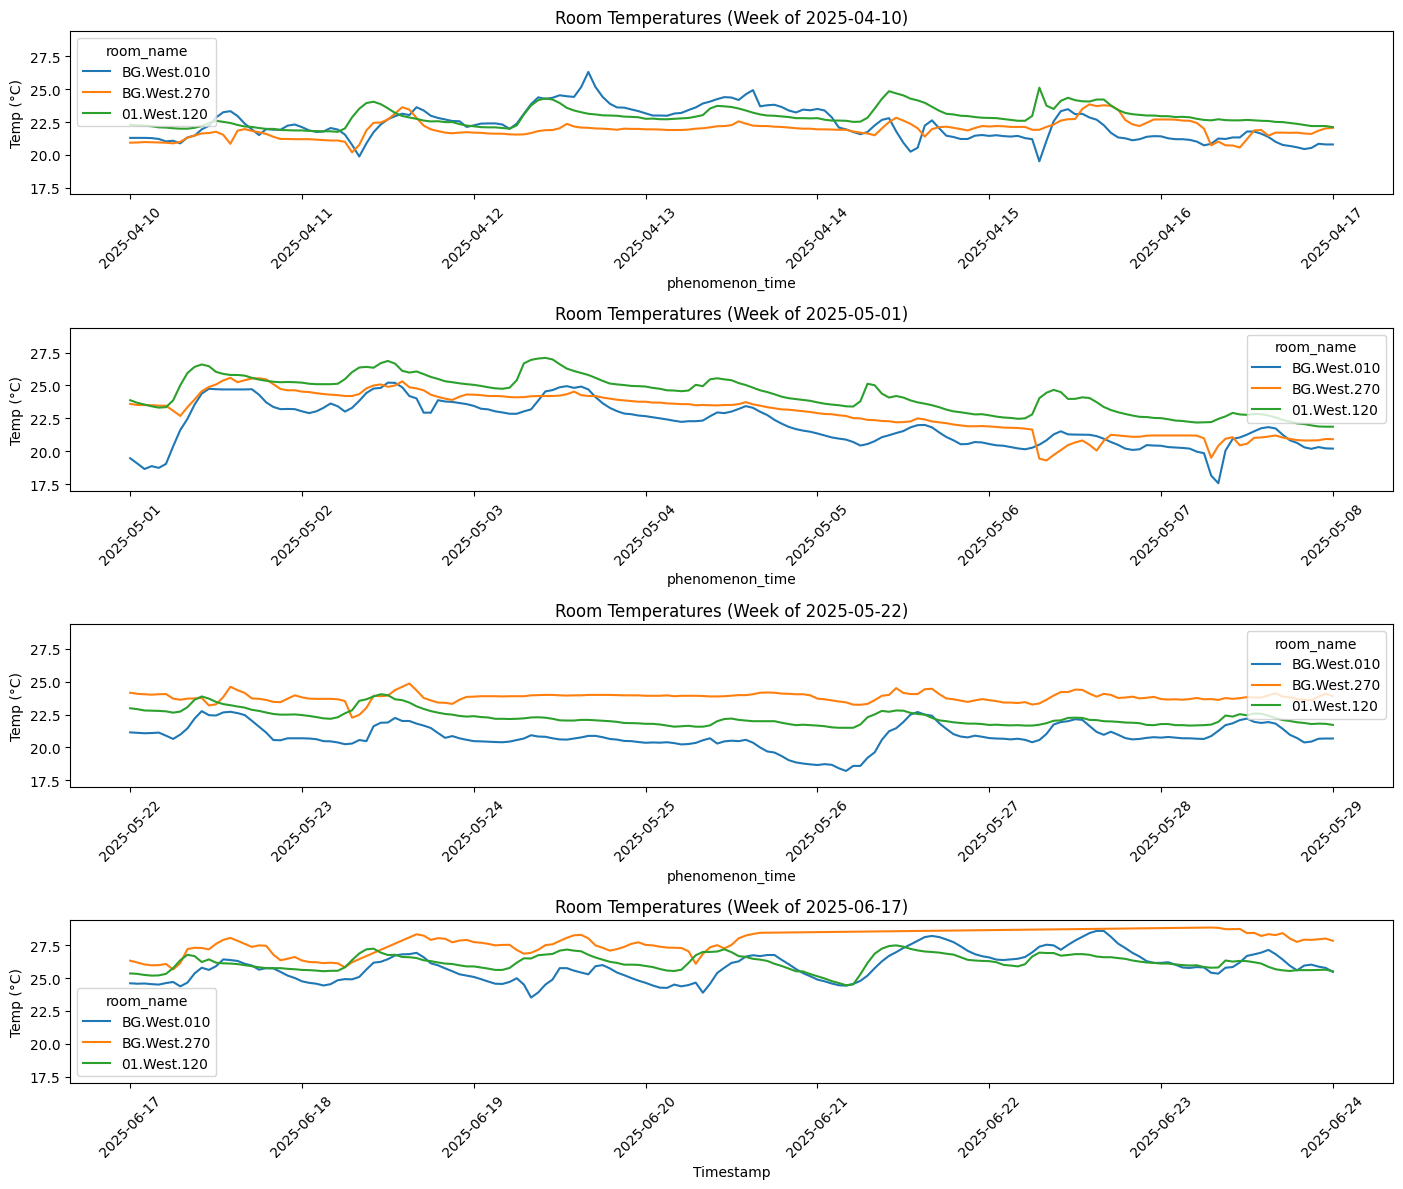

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure datetime is in correct format
df_temp_hourly["phenomenon_time"] = pd.to_datetime(df_temp_hourly["phenomenon_time"])

# ── Step 1: Define four weekly time ranges ──
week_ranges = [
    ("2025-04-10", "2025-04-17"),
    ("2025-05-01", "2025-05-08"),
    ("2025-05-22", "2025-05-29"),
    ("2025-06-17", "2025-06-24"),
]

# ── Step 2: Create subplots ──
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharey=True)

# ── Step 3: Filter and plot each week ──
for i, (start_date, end_date) in enumerate(week_ranges):
    week_data = df_temp_hourly[
        (df_temp_hourly["phenomenon_time"] >= start_date) &
        (df_temp_hourly["phenomenon_time"] <= end_date)
    ].copy()

    sns.lineplot(
        data=week_data,
        x="phenomenon_time",
        y="internal_temp",
        hue="room_name",
        ax=axes[i]
    )
    axes[i].set_title(f"Room Temperatures (Week of {start_date})")
    axes[i].set_ylabel("Temp (°C)")
    axes[i].tick_params(axis='x', rotation=45)

# ── Step 4: Label the final x-axis ──
axes[-1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

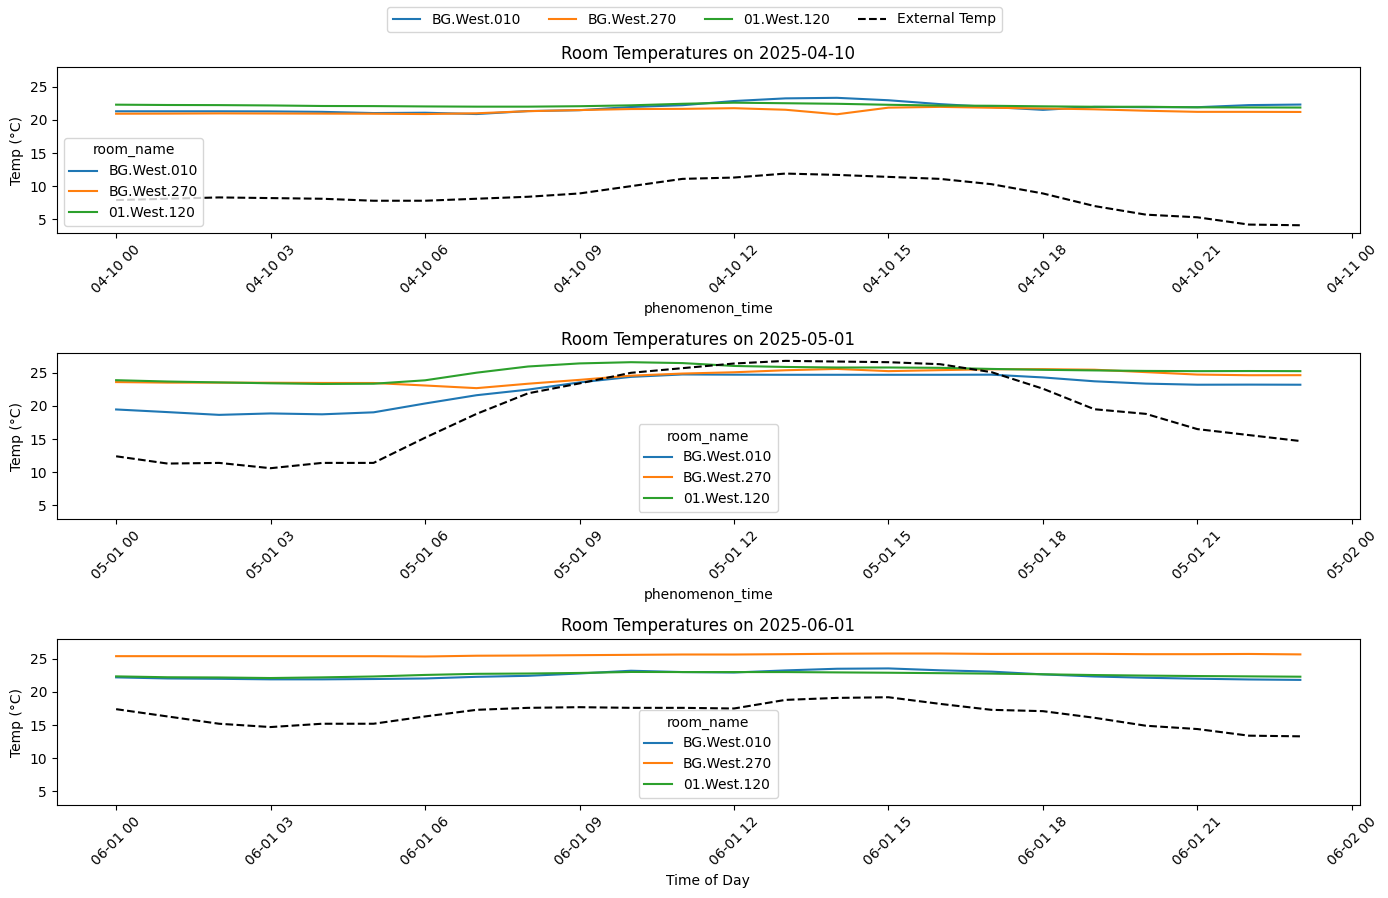

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from meteostat import Point, Hourly
from datetime import datetime

# TU Delft Bouwkunde coordinates - used for accessing external temperature data
bk_site = Point(52.0056, 4.3707, 0)
# Date range to fetch external temps (April to June)
start = datetime(2025, 4, 1)
end = datetime(2025, 6, 30)
# Fetch external hourly temperature
external_temp_combined = Hourly(bk_site, start, end).fetch()
external_temp_combined = external_temp_combined.reset_index()

# Keep only timestamp and temperature
external_temp_combined = external_temp_combined[["time", "temp"]]
external_temp_combined.columns = ["phenomenon_time", "external_temp"]
# Ensure datetime format
df_temp_hourly["phenomenon_time"] = pd.to_datetime(df_temp_hourly["phenomenon_time"])
external_temp_combined["phenomenon_time"] = pd.to_datetime(external_temp_combined["phenomenon_time"])

# ── Define target dates ──
target_dates = [
    ("2025-04-10", "2025-04-11"),
    ("2025-05-01", "2025-05-02"),
    ("2025-06-01", "2025-06-02"),
]

# ── Create subplots ──
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharey=True)

# ── Plot each date ──
for i, (start_date, end_date) in enumerate(target_dates):
    day_data = df_temp_hourly[
        (df_temp_hourly["phenomenon_time"] >= start_date) &
        (df_temp_hourly["phenomenon_time"] < end_date)
    ].copy()
    # Filter external temp data
    ext_data = external_temp_combined[
        (external_temp_combined["phenomenon_time"] >= start_date) &
        (external_temp_combined["phenomenon_time"] < end_date)
    ].copy()

    sns.lineplot(
        data=day_data,
        x="phenomenon_time",
        y="internal_temp",
        hue="room_name",
        ax=axes[i]
    )
    # Plot external temp (as a single dashed line)
    label = "External Temp" if i == 0 else None
    axes[i].plot(
        ext_data["phenomenon_time"],
        ext_data["external_temp"],
        color="black",
        linestyle="--",
        label=label
    )
    axes[i].set_title(f"Room Temperatures on {start_date}")
    axes[i].set_ylabel("Temp (°C)")
    axes[i].tick_params(axis='x', rotation=45)

# Add global legend (handles both hue and manual line)
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4)

axes[-1].set_xlabel("Time of Day")
plt.tight_layout(rect=[0, 0, 1, 0.97])  # Leave space for legend at top
plt.show()

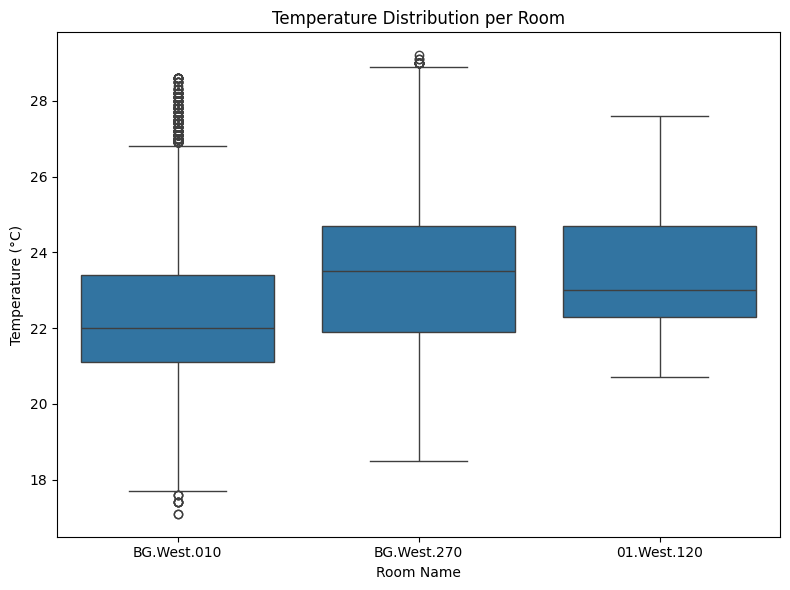

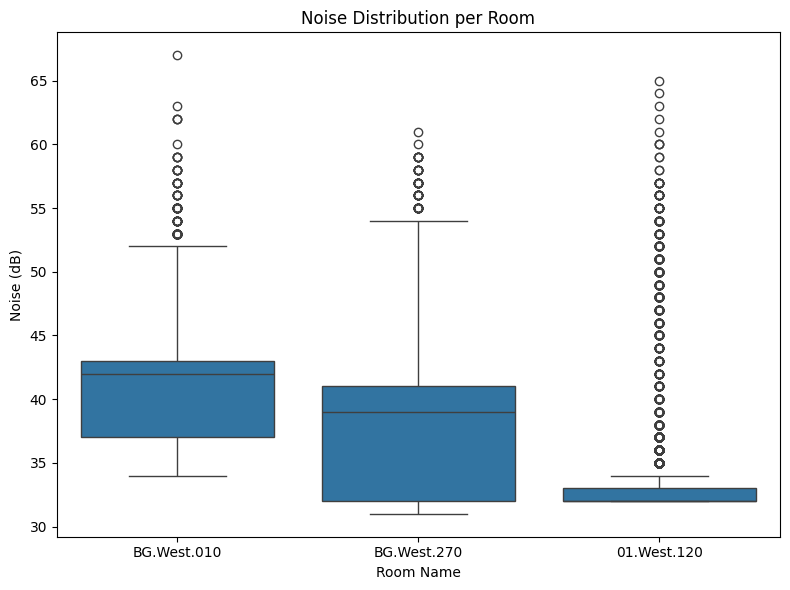

In [34]:

# --------- Boxplot: Temperature Distribution ---------
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_temp_cleaned, x="room_name", y="internal_temp")
plt.title("Temperature Distribution per Room")
plt.xlabel("Room Name")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

# --------- Boxplot: Noise Distribution ---------
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_noise_cleaned, x="room_name", y="noise")
plt.title("Noise Distribution per Room")
plt.xlabel("Room Name")
plt.ylabel("Noise (dB)")
plt.tight_layout()
plt.show()
